In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [29]:
df = pd.read_csv("cancer_risk_dataset.csv")
df.head(12)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium
5,LU0005,Lung,77,1,10,8,3,0,6,0,...,2,10,7,0,0,0,0.498668,25.1,1,Medium
6,LU0006,Lung,59,0,10,10,0,0,9,4,...,1,10,9,0,0,5,0.662354,32.3,2,High
7,LU0007,Prostate,74,1,8,6,2,1,3,3,...,8,8,7,0,0,1,0.479367,29.1,9,Medium
8,LU0008,Colon,71,1,9,0,3,0,10,4,...,10,8,3,0,0,5,0.497620,24.1,5,Medium
9,LU0009,Skin,55,1,7,1,2,0,0,4,...,5,9,9,0,0,5,0.404837,28.2,1,Medium


In [196]:
df[df["Risk_Level"] == "Medium"]

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium
5,LU0005,Lung,77,1,10,8,3,0,6,0,...,2,10,7,0,0,0,0.498668,25.1,1,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,ST0394,Skin,67,1,5,1,6,0,3,0,...,0,5,10,0,0,4,0.343532,27.4,5,Medium
1995,ST0395,Colon,60,1,4,6,4,0,10,6,...,4,5,3,1,0,4,0.437539,30.3,3,Medium
1996,ST0396,Prostate,84,1,5,7,8,0,10,0,...,2,1,3,0,0,2,0.451128,25.9,4,Medium
1998,ST0398,Lung,64,1,10,2,10,0,2,10,...,5,4,2,0,0,10,0.422201,25.3,3,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

# Existe desbalance de clases

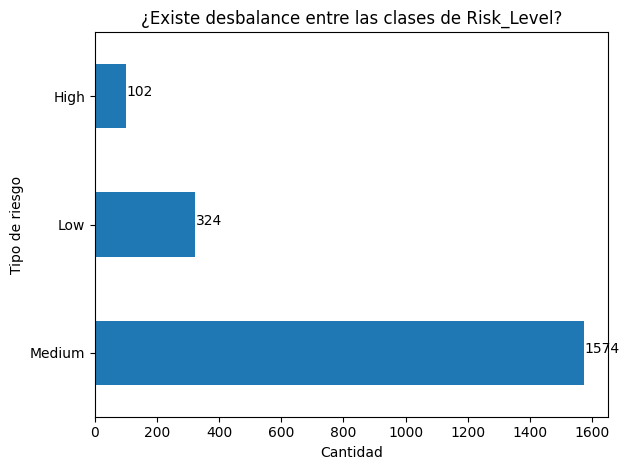

In [50]:
df.Risk_Level.value_counts().plot.barh()
plt.title("¿Existe desbalance entre las clases de Risk_Level?")

for i, val in enumerate(df.Risk_Level.value_counts().values) : 
    plt.text(val, i, val)
plt.ylabel("Tipo de riesgo")
plt.xlabel("Cantidad")
plt.tight_layout()

# Mapa de correlación

<Axes: >

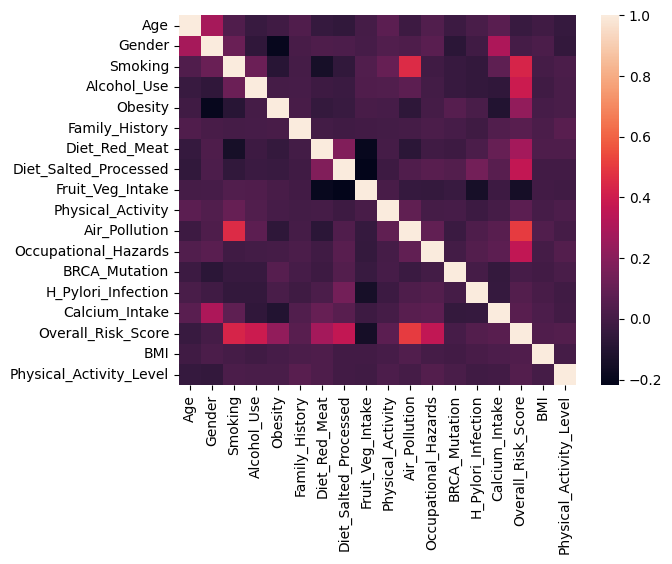

In [7]:
sns.heatmap(df.select_dtypes(["int64", "float64"]).corr())

# Entrenamiento del modelo

In [184]:
X = df.drop(["Risk_Level", "Overall_Risk_Score"], axis=1).select_dtypes(["int64", "float64"])
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [31]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
rf.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluación del modelo

Evaluación del modelo en general

In [33]:
pred = rf.predict(X_test)
print(accuracy_score(Y_test, pred))

0.8575


Existe desbalance de clases, evaluemos qué tan bien predice el modelo a la clase de riesgo High

Idea: Solo tomaremos los valores de X_test cuyo risk sea "High", y luego los pasaremos a predecir para ver los resultados

In [157]:
high = df[df["Risk_Level"] == "High"]


In [170]:
indexes = X_test.index.values
dropped = []
for i in high.index.values:
    if(i not in indexes):
        dropped.append(i)

X_test_high = high.drop(dropped)
X_test_high = X_test_high.drop(["Risk_Level", "Overall_Risk_Score"], axis=1).select_dtypes(["int64", "float64"])

In [179]:

pred = rf.predict(X_test_high)
print(accuracy_score(high["Risk_Level"].drop(dropped), pred))

0.0625


La predicción es muy mala, predice a la mayoría como "Medium"

In [180]:
pred

array(['Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'High', 'Medium'], dtype=object)

<Axes: title={'center': 'Clases con mayor influencia durante entrenamiento del modelo Random Forest'}>

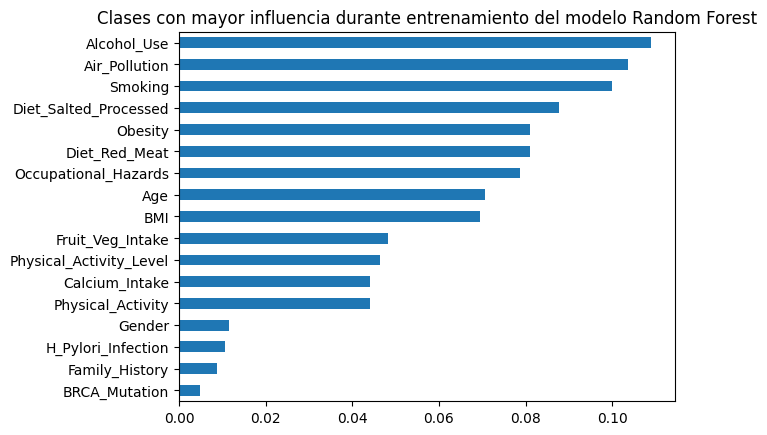

In [173]:
br = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.title("Clases con mayor influencia durante entrenamiento del modelo Random Forest")
br.plot.barh()

In [70]:
from sklearn.metrics import confusion_matrix

In [91]:
cm = confusion_matrix(high["Risk_Level"], pred)
cm = pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns= ['Predicted Negative', 'Predicted Positive'])

<Axes: >

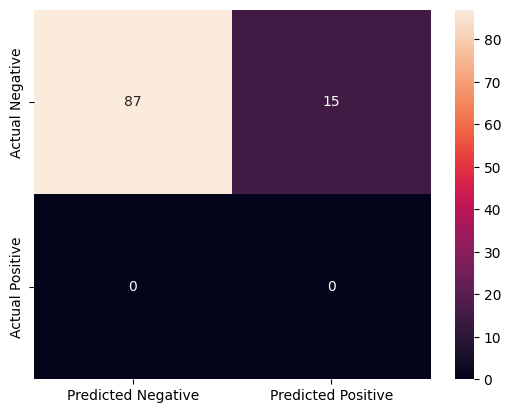

In [99]:

sns.heatmap(cm, annot=True)